In [ ]:
# 1. INSTALLATION AND DRIVE SETUP
# ----------------------------------------------------------------
!pip install roboflow
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from roboflow import Roboflow
import matplotlib.pyplot as plt

# Mount Google Drive to save the model and history permanently
from google.colab import drive
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/v11_improved'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Results will be saved to: {SAVE_PATH}")


# 2. ROBOFLOW DOWNLOAD
# ----------------------------------------------------------------
# Initialize Roboflow and download the augmented dataset
# Please ensure this API Key and Version are for your latest Augmented Dataset
rf = Roboflow(api_key="lMGrqj6xSUfkU7FUVosZ")
project = rf.workspace("first-training-asi3d").project("dataset-kuidk")
version = project.version(1)
dataset = version.download("folder")

# Define Paths
dataset_path = dataset.location
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "valid")
test_dir = os.path.join(dataset_path, "test")

print(f"\nData successfully downloaded to: {dataset_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/v11_improved
loading Roboflow workspace...
loading Roboflow project...

Data successfully downloaded to: /content/DATASET-1


In [ ]:
# 3. DATA GENERATORS (ResNet Specific)
# ----------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Use ResNet's specific preprocessing function (BGR conversion and zero-centering)
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("\n--- Loading Training Data ---")
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\n--- Loading Validation Data ---")
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n--- Loading Test Data ---")
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)
print(f"Detected {NUM_CLASSES} classes: {train_generator.class_indices}")


--- Loading Training Data ---
Found 1743 images belonging to 2 classes.

--- Loading Validation Data ---
Found 167 images belonging to 2 classes.

--- Loading Test Data ---
Found 83 images belonging to 2 classes.
Detected 2 classes: {'STRABISMUS': 0, 'STRABISMUS_FREE': 1}


In [ ]:
# 4. MODEL ARCHITECTURE (ResNet50 v12)
# ----------------------------------------------------------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# PHASE 1: FREEZE the base model
base_model.trainable = False

# Create the new head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# 5. PHASE 1: TRANSFER LEARNING (Frozen)
# ----------------------------------------------------------------
print("\n--- Starting PHASE 1: Transfer Learning (20 Epochs) ---")

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train for 20 epochs to stabilize the new dense layers
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose=1
)

# Save the model after Phase 1 (optional checkpoint)
model.save(os.path.join(SAVE_PATH, "smartsight_resnet50_p1_checkpoint.h5"))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting PHASE 1: Transfer Learning (20 Epochs) ---


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.6418 - loss: 1.4653 - val_accuracy: 0.8263 - val_loss: 0.3909
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.7791 - loss: 0.4526 - val_accuracy: 0.8204 - val_loss: 0.3592
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8256 - loss: 0.3951 - val_accuracy: 0.8743 - val_loss: 0.3015
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.8529 - loss: 0.3344 - val_accuracy: 0.8922 - val_loss: 0.2816
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8463 - loss: 0.3321 - val_accuracy: 0.8623 - val_loss: 0.3170
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8580 - loss: 0.3170 - val_accuracy: 0.8862 - val_loss: 0.2852
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8790 - loss: 0.2765 - val_accuracy: 0.8383 - val_loss: 0.3460
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.8867 - loss: 0.2674 - val_accuracy: 0.8802 

In [ ]:
# 6. PHASE 2: FINE-TUNING (Unfrozen)
# ----------------------------------------------------------------
print("\n--- Starting PHASE 2: Fine-Tuning (Total 150 Epochs) ---")

# Unfreeze the base model
base_model.trainable = True

# CRITICAL: Freeze BatchNormalization layers for stability during fine-tuning
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a VERY LOW learning rate for fine-tuning
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define Callbacks
checkpoint_path = os.path.join(SAVE_PATH, "smartsight_resnet50_best.h5")
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20, # Patience requested: 20
                               restore_best_weights=True,
                               verbose=1)

TOTAL_EPOCHS = 150

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=20, # Continue from epoch 20
    callbacks=[checkpoint, reduce_lr, early_stopping]
)


# 7. FINAL EVALUATION & SAVING
# ----------------------------------------------------------------
print("\n--- Final Evaluation on Test Set ---")
# Reload the best weights saved by ModelCheckpoint before evaluation
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")


# 8. SAVE FINAL MODEL AND TRAINING HISTORY
# ----------------------------------------------------------------

# SAVE FINAL MODEL as H5 (As Requested)
final_model_path = os.path.join(SAVE_PATH, "smartsight_resnet50_final_v12.h5")
model.save(final_model_path)
print(f"Final Model saved at: {final_model_path}")


# SAVE TRAINING HISTORY (Combined Phases 1 & 2)
# Combine histories from both phases for continuous plotting
history_data = {}
for k in history_phase1.history.keys():
    # p1 history contains epochs 0-19, p2 contains 20-end
    p1 = [float(x) for x in history_phase1.history[k]]
    p2 = [float(x) for x in history_phase2.history[k]]
    history_data[k] = p1 + p2

history_file = os.path.join(SAVE_PATH, "history_v12.json")
with open(history_file, "w") as f:
    json.dump(history_data, f, indent=4)

print(f"Training history (loss/accuracy) saved to: {history_file}")


--- Starting PHASE 2: Fine-Tuning (Total 150 Epochs) ---
Epoch 21/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9086 - loss: 0.2268
Epoch 21: val_accuracy improved from -inf to 0.89820, saving model to /content/drive/MyDrive/v11_improved/smartsight_resnet50_best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 727ms/step - accuracy: 0.9088 - loss: 0.2264 - val_accuracy: 0.8982 - val_loss: 0.2245 - learning_rate: 1.0000e-05
Epoch 22/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9754 - loss: 0.0846
Epoch 22: val_accuracy did not improve from 0.89820
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 285ms/step - accuracy: 0.9753 - loss: 0.0846 - val_accuracy: 0.8743 - val_loss: 0.4238 - learning_rate: 1.0000e-05
Epoch 23/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9873 - loss: 0.0520
Epoch 23: val_accuracy improved from 0.89820 to 0.91018, saving model to /content/drive/MyDrive/v11_improved/smartsight_resnet50_best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 412ms/step - accuracy: 0.9872 - loss: 0.0521 - val_accuracy: 0.9102 - val_loss: 0.2241 - learning_rate: 1.0000e-05
Epoch 24/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9932 - loss: 0.0225
Epoch 24: val_accuracy improved from 0.91018 to 0.91617, saving model to /content/drive/MyDrive/v11_improved/smartsight_resnet50_best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 367ms/step - accuracy: 0.9932 - loss: 0.0226 - val_accuracy: 0.9162 - val_loss: 0.2395 - learning_rate: 1.0000e-05
Epoch 25/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9929 - loss: 0.0203
Epoch 25: val_accuracy did not improve from 0.91617
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step - accuracy: 0.9929 - loss: 0.0203 - val_accuracy: 0.9042 - val_loss: 0.2971 - learning_rate: 1.0000e-05
Epoch 26/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9984 - loss: 0.0120
Epoch 26: val_accuracy did not improve from 0.91617
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 297ms/step - accuracy: 0.9983 - loss: 0.0120 - val_accuracy: 0.9042 - val_loss: 0.2836 - learning_rate: 1.0000e-05
Epoch 27/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9968 - loss: 0.0103
Epoch 27: val_accuracy did not improve from 0.91617
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 282ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9162 - val_loss: 0.2477 - learning_rate: 1.0000e

55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 412ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9222 - val_loss: 0.2909 - learning_rate: 2.0000e-06
Epoch 32/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 32: val_accuracy did not improve from 0.92216
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9222 - val_loss: 0.2924 - learning_rate: 2.0000e-06
Epoch 33/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 33: val_accuracy did not improve from 0.92216

Epoch 33: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 290ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9162 - val_loss: 0.2985 - learning_rate: 2.0000e-06
Epoch 34/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 34: val_accuracy did not improve from 0.92216
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 288ms/step - accuracy: 1.0000 - l

Test Loss: 0.1289
Test Accuracy: 93.98%
Final Model saved at: /content/drive/MyDrive/v11_improved/smartsight_resnet50_final_v12.h5
Training history (loss/accuracy) saved to: /content/drive/MyDrive/v11_improved/history_v12.json


In [ ]:
import os
import numpy as np
import json
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from roboflow import Roboflow

# --- Setup Paths (Assumed to be correct from previous cell) ---
SAVE_PATH = '/content/drive/MyDrive/v11_improved'
MODEL_PATH = os.path.join(SAVE_PATH, "smartsight_resnet50_final_v12.h5")
# The TEST_DIR path must be correct based on the download output: /content/DATASET-1/test
DATASET_PATH = "/content/DATASET-1"
TEST_DIR = os.path.join(DATASET_PATH, "test")

# Define the final result variables from your previous run (93.98%)
test_acc = 0.9398
test_loss = 0.1289

# --- 1. Load the Model and Data Generator ---
print("Loading the final model from Google Drive...")
# Using try-except for robust loading
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception:
    print("WARNING: Could not load final model. Attempting to load best checkpoint.")
    CHECKPOINT_PATH = os.path.join(SAVE_PATH, "smartsight_resnet50_best.h5")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)


# Recreate the Test Generator (CRUCIAL: shuffle=False)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print(f"Detected Class Names: {class_names}")

# --- 2. Generate Predictions (FIX APPLIED HERE) ---
print("\nGenerating predictions on the test set...")

# FIX: Calculate steps and explicitly cast to integer type
steps = int(np.ceil(test_generator.samples / BATCH_SIZE))

predictions = model.predict(test_generator, steps=steps)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes


# --- 3. Generate and Save Reports ---
report_text = classification_report(true_classes, predicted_classes, target_names=class_names)
print("\n--- Classification Report ---")
print(report_text)

report_path = os.path.join(SAVE_PATH, "classification_report_v12.txt")
with open(report_path, "w") as f:
    f.write(report_text)
print(f"Report saved to: {report_path}")


# --- 4. Plot Confusion Matrix ---
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix v12 (Test Accuracy: {test_acc*100:.2f}%)')
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix_v12.png'))
plt.close()
print(f"Confusion Matrix image saved to: {os.path.join(SAVE_PATH, 'confusion_matrix_v12.png')}")


# --- 5. Plot Training History (Loss & Accuracy) ---
HISTORY_PATH = os.path.join(SAVE_PATH, "history_v12.json")
try:
    with open(HISTORY_PATH, 'r') as f:
        history_data = json.load(f)

    epochs = range(len(history_data['accuracy']))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_data['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_data['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_data['loss'], label='Training Loss')
    plt.plot(epochs, history_data['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.savefig(os.path.join(SAVE_PATH, 'accuracy_loss_history_v12.png'))
    plt.close()
    print(f"History Plot saved to: {os.path.join(SAVE_PATH, 'accuracy_loss_history_v12.png')}")

except FileNotFoundError:
    print(f"History file not found at {HISTORY_PATH}. Cannot generate history plot. Ensure Google Drive is mounted and the path is correct.")

Loading the final model from Google Drive...


Found 83 images belonging to 2 classes.
Detected Class Names: ['STRABISMUS', 'STRABISMUS_FREE']

Generating predictions on the test set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

--- Classification Report ---
                 precision    recall  f1-score   support

     STRABISMUS       0.95      0.93      0.94        42
STRABISMUS_FREE       0.93      0.95      0.94        41

       accuracy                           0.94        83
      macro avg       0.94      0.94      0.94        83
   weighted avg       0.94      0.94      0.94        83

Report saved to: /content/drive/MyDrive/v11_improved/classification_report_v12.txt
Confusion Matrix image saved to: /content/drive/MyDrive/v11_improved/confusion_matrix_v12.png
History Plot saved to: /content/drive/MyDrive/v11_improved/accuracy_loss_history_v12.png


In [ ]:
import tensorflow as tf
import os

# --- 1. DEFINE PATHS ---
# !!! CRITICAL: Replace this entire string with the ABSOLUTE LOCAL FILE PATH !!!
# Example: 'C:/Users/YourName/Downloads/smartsight_resnet50_final_v12.h5'
H5_MODEL_PATH = '/content/drive/MyDrive/v11_improved/smartsight_resnet50_final_v12.h5'
TFLITE_MODEL_PATH = 'smartsight_resnet50_v12.tflite'

# Flag to track if the model loaded successfully
model_loaded = False
model = None # Initialize model variable

# --- 2. LOAD AND CONVERT ---
try:
    print(f"Loading Keras model from: {H5_MODEL_PATH}")
    # Load the model without compiling, as we only need the structure and weights
    model = tf.keras.models.load_model(H5_MODEL_PATH, compile=False)
    model_loaded = True
except Exception as e:
    print(f"\n[CRITICAL ERROR] Could not load the H5 model.")
    print(f"The path '{H5_MODEL_PATH}' is incorrect or the file is missing.")
    print(f"Full error details: {e}")

if not model_loaded:
    print("\n[CONVERSION ABORTED] Please correct the H5_MODEL_PATH and run again.")
else:
    # --- 3. CONVERSION STEPS ---

    # Initialize the TFLite Converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Apply Optimization (Quantization)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Perform the conversion
    print("Converting model to optimized TFLite format...")
    tflite_model = converter.convert()

    # --- 4. SAVE THE TFLITE MODEL ---
    with open(TFLITE_MODEL_PATH, 'wb') as f:
        f.write(tflite_model)

    # --- 5. REPORT RESULTS ---
    h5_size = os.path.getsize(H5_MODEL_PATH) / (1024 * 1024)
    tflite_size = os.path.getsize(TFLITE_MODEL_PATH) / (1024 * 1024)

    print("\n-------------------------------------------------------")
    print(" TFLite Conversion Complete!")
    print(f"  Original H5 Size: {h5_size:.2f} MB")
    print(f"  TFLite Size:      {tflite_size:.2f} MB (Optimized for mobile)")
    print(f"  Saved TFLite model to: {TFLITE_MODEL_PATH}")
    print("-------------------------------------------------------")

Loading Keras model from: /content/drive/MyDrive/v11_improved/smartsight_resnet50_final_v12.h5
Converting model to optimized TFLite format...
Saved artifact at '/tmp/tmple0r9ykj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135052671390672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135050217047632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135047764442384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135047764441808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135052671390864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135047764442192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135047764442768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135047764441424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1350477644425

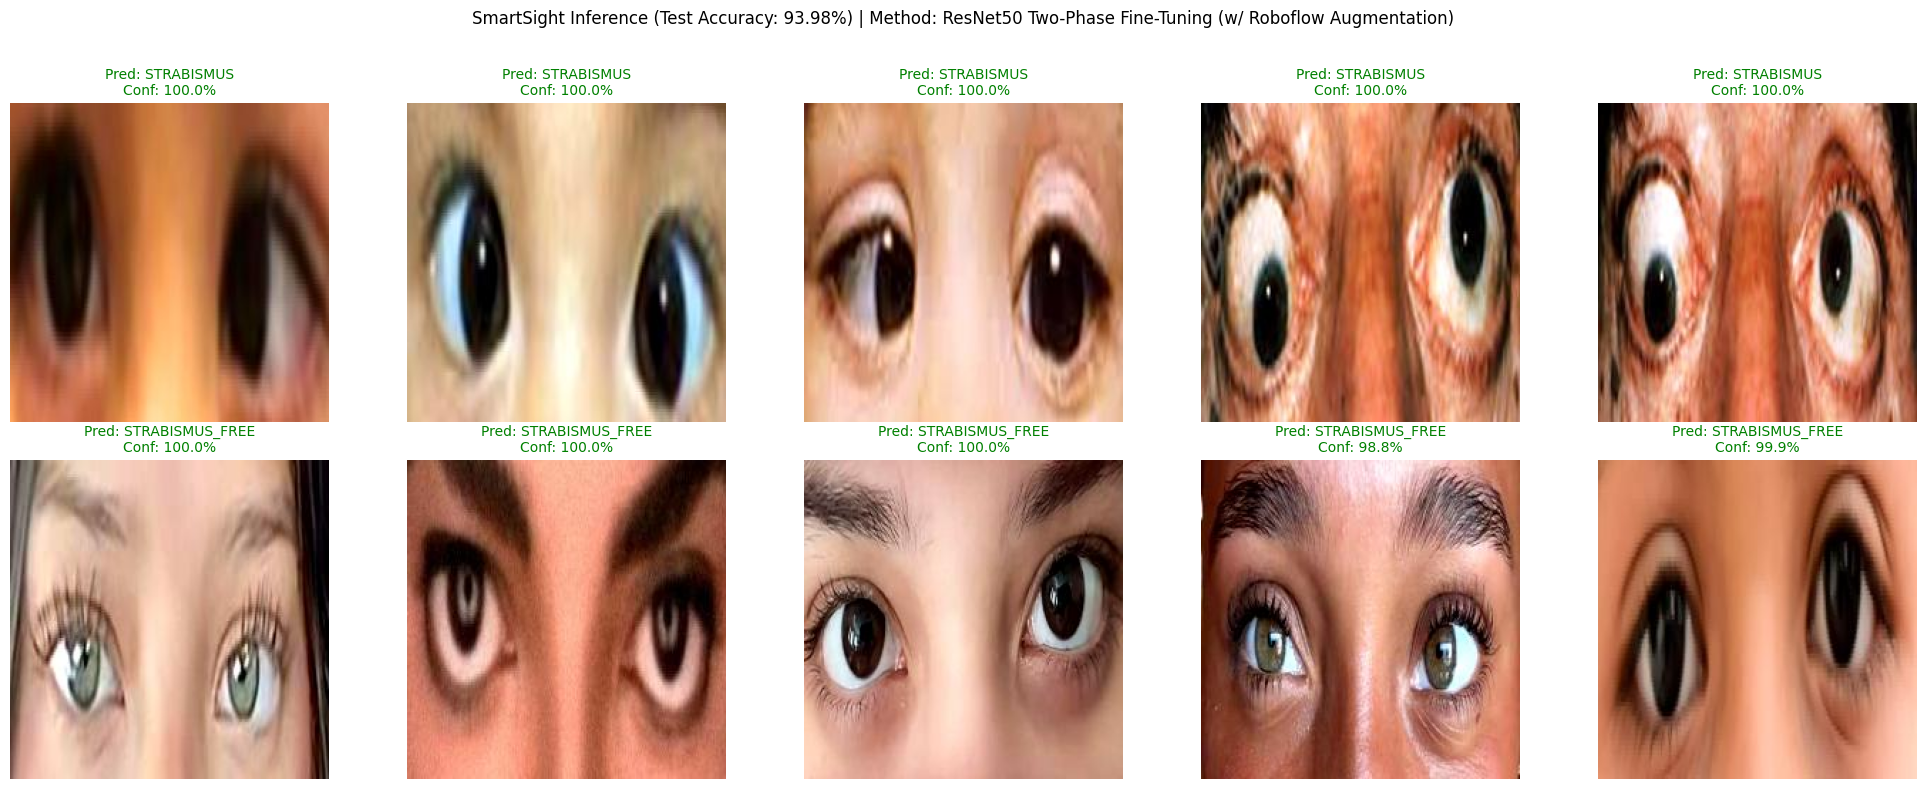


Model: ResNet50 Two-Phase Fine-Tuning (w/ Roboflow Augmentation)
 10-Sample Inference Visualization saved to: /content/drive/MyDrive/v11_improved/10_sample_inferences_v12.png


In [ ]:
# --- RUN THIS CELL: 10-SAMPLE INFERENCE GRID (5 per Class) ---
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import load_model

# --- Training Context for Thesis ---
MODEL_ACCURACY = 93.98
MODEL_METHOD = "ResNet50 Two-Phase Fine-Tuning (w/ Roboflow Augmentation)"

# --- Setup Paths ---
# CRITICAL: Ensure these paths are correct for your current Colab session
TEST_DIR = "/content/DATASET-1/test"
SAVE_PATH = '/content/drive/MyDrive/v11_improved'

# Define classes based on the detected indices: {'STRABISMUS': 0, 'STRABISMUS_FREE': 1}
ACTUAL_CLASS_NAMES = ['STRABISMUS', 'STRABISMUS_FREE']
IMG_SIZE = (224, 224)

# Load the final model
model = load_model(os.path.join(SAVE_PATH, "smartsight_resnet50_final_v12.h5"), compile=False)


def plot_multiple_inferences(model, class_names, test_dir, n_samples=5):
    """Selects n_samples from each class, predicts, and plots the results in a 2xN grid."""

    image_paths = []

    # 1. Collect 5 random image paths for each class
    for class_name in class_names:
        class_dir = os.path.join(test_dir, class_name)

        if not os.path.isdir(class_dir):
            print(f"Directory not found: {class_dir}. Check that the data is downloaded.")
            return

        files = [f for f in os.listdir(class_dir) if f.endswith(('jpg', 'jpeg', 'png'))]

        # Select n_samples or all files if fewer exist
        selected_files = random.sample(files, min(len(files), n_samples))

        for file in selected_files:
            image_paths.append(os.path.join(class_dir, file))

    # 2. Set up the plot grid (2 rows: Class 0, Class 1; 5 columns)
    fig, axes = plt.subplots(nrows=2, ncols=n_samples, figsize=(20, 8))
    fig.suptitle(f"SmartSight Inference (Test Accuracy: {MODEL_ACCURACY:.2f}%) | Method: {MODEL_METHOD}", fontsize=12)

    # 3. Process, Predict, and Plot
    for i, img_path in enumerate(image_paths):
        true_class_folder = os.path.basename(os.path.dirname(img_path))

        # Determine subplot location: Row 0 for STRABISMUS (Index 0), Row 1 for STRABISMUS_FREE (Index 1)
        # This mapping is based on the detected indices: {'STRABISMUS': 0, 'STRABISMUS_FREE': 1}
        if true_class_folder == class_names[0]:
            row = 0 # STRABISMUS
            col = i
        else:
            row = 1 # STRABISMUS_FREE
            col = i - n_samples

        # Load and preprocess image
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        processed_img = preprocess_input(img_array.copy())

        # Make prediction
        predictions = model.predict(processed_img, verbose=0)
        score = predictions[0]
        predicted_class_index = np.argmax(score)
        predicted_class_name = class_names[predicted_class_index]
        confidence = score[predicted_class_index] * 100

        # Plotting
        ax = axes[row, col]
        ax.imshow(img)

        # Color title based on correctness
        is_correct = (predicted_class_name == true_class_folder)
        color = 'green' if is_correct else 'red'

        title = f"Pred: {predicted_class_name}\nConf: {confidence:.1f}%"

        ax.set_title(title, fontsize=10, color=color)
        ax.axis('off')

    # Add descriptive row labels
    row_titles = [f"True Class: {class_names[0]}", f"True Class: {class_names[1]}"]
    for ax, title in zip(axes[:, 0], row_titles):
        ax.set_ylabel(title, rotation=90, size='large', labelpad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    output_path = os.path.join(SAVE_PATH, '10_sample_inferences_v12.png')
    plt.savefig(output_path)
    plt.show()
    print(f"\nModel: {MODEL_METHOD}")
    print(f" 10-Sample Inference Visualization saved to: {output_path}")

# Run the function
plot_multiple_inferences(model, ACTUAL_CLASS_NAMES, TEST_DIR, n_samples=5)

In [ ]:
# --- RUN THIS CELL FIRST to create the evaluation_summary_v12.json ---
import os
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Define Paths and Constants
SAVE_PATH = '/content/drive/MyDrive/v11_improved'
MODEL_PATH = os.path.join(SAVE_PATH, "smartsight_resnet50_final_v12.h5")
TEST_DIR = "/content/DATASET-1/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Load Model and Data Generator
print("Loading model and recreating test generator...")
model = tf.keras.models.load_model(MODEL_PATH)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# 2. Evaluate and Predict
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

steps = int(np.ceil(test_generator.samples / BATCH_SIZE))
predictions = model.predict(test_generator, steps=steps)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())


# 3. Generate Classification Report and Save to JSON
report_dict = classification_report(true_classes, predicted_classes, target_names=class_names, output_dict=True)

evaluation_summary = {
    "Test Accuracy": f"{test_acc*100:.2f}%",
    "Test Loss": f"{test_loss:.4f}",
    "Classification Report": report_dict
}

summary_path = os.path.join(SAVE_PATH, "evaluation_summary_v12.json")
with open(summary_path, "w") as f:
    json.dump(evaluation_summary, f, indent=4)

print(f"\n Evaluation Summary JSON successfully recreated and saved at: {summary_path}")

Loading model and recreating test generator...


Found 83 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Evaluation Summary JSON successfully recreated and saved at: /content/drive/MyDrive/v11_improved/evaluation_summary_v12.json


Loading the final model...
Found 83 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


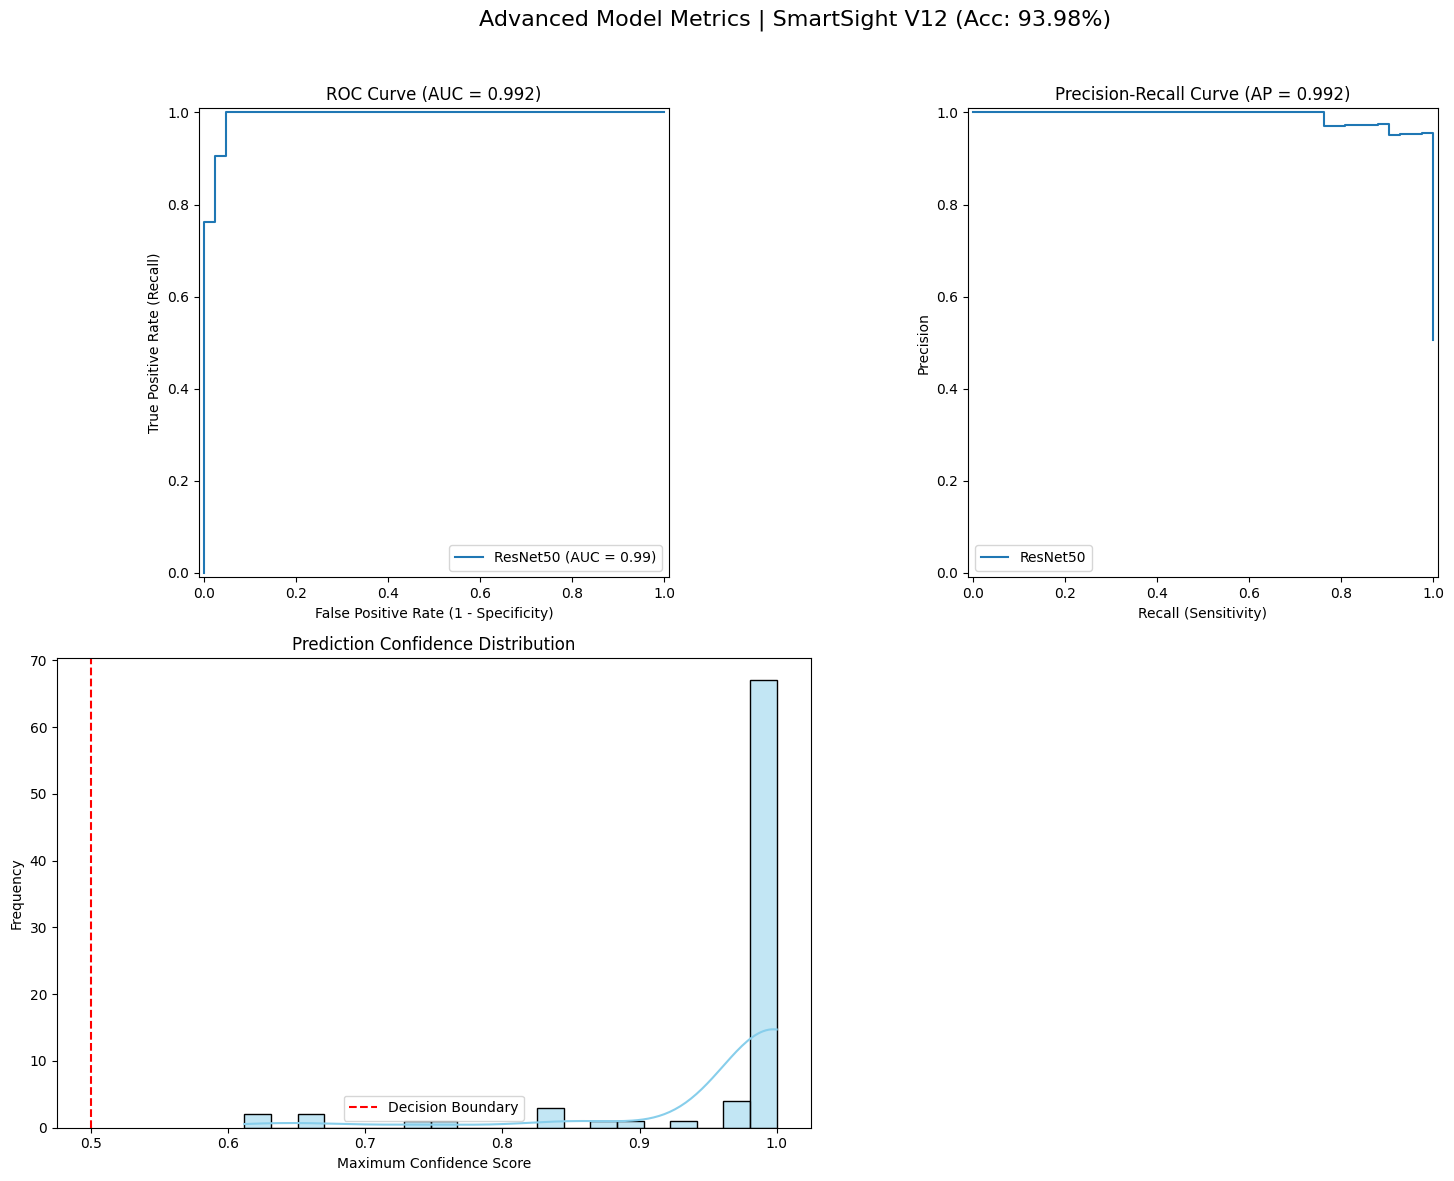


 Advanced Metrics Plot (ROC, PR, Confidence) saved to: /content/drive/MyDrive/v11_improved/advanced_metrics_v12.png


In [ ]:
# --- FINAL CLEAN PLOTTING SCRIPT (Advanced Metrics Only) ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import tensorflow as tf
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay, classification_report, average_precision_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# --- 1. SETUP & DATA LOADING ---
# Ensure these paths are correct from your successful run
SAVE_PATH = '/content/drive/MyDrive/v11_improved'
MODEL_PATH = os.path.join(SAVE_PATH, "smartsight_resnet50_final_v12.h5")
TEST_DIR = "/content/DATASET-1/test"

# Define constants (from successful training)
TEST_ACCURACY = 93.98
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
POSITIVE_CLASS_INDEX = 0  # STRABISMUS
POSITIVE_CLASS_NAME = 'STRABISMUS'

# Load Model
print("Loading the final model...")
model = load_model(MODEL_PATH, compile=False)

# Recreate Test Generator
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Get class names
class_names = list(test_generator.class_indices.keys())

# --- 2. GENERATE PREDICTIONS ---
steps = int(np.ceil(test_generator.samples / BATCH_SIZE))
predictions_proba = model.predict(test_generator, steps=steps)

# Probabilities and True Labels
y_pred_proba = predictions_proba[:, POSITIVE_CLASS_INDEX]
y_true_binary = (test_generator.classes == POSITIVE_CLASS_INDEX).astype(int)
predicted_classes = np.argmax(predictions_proba, axis=1)
true_classes = test_generator.classes


# --- 3. GENERATE ALL PLOTS ---
plt.figure(figsize=(16, 12))
plt.suptitle(f"Advanced Model Metrics | SmartSight V12 (Acc: {TEST_ACCURACY:.2f}%)", fontsize=16)

# == Plot 1: ROC Curve ==
plt.subplot(2, 2, 1)
fpr, tpr, thresholds = roc_curve(y_true_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ResNet50').plot(ax=plt.gca())
plt.title(f'ROC Curve (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')


# == Plot 2: Precision-Recall Curve ==
plt.subplot(2, 2, 2)
precision, recall, _ = precision_recall_curve(y_true_binary, y_pred_proba)
avg_precision = average_precision_score(y_true_binary, y_pred_proba)
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='ResNet50').plot(ax=plt.gca())
plt.title(f'Precision-Recall Curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')


# == Plot 3: Prediction Confidence Histogram ==
plt.subplot(2, 2, 3)
confidence = np.max(predictions_proba, axis=1)

sns.histplot(confidence, bins=20, kde=True, color='skyblue', edgecolor='black')
plt.axvline(x=0.5, color='r', linestyle='--', label='Decision Boundary')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Maximum Confidence Score')
plt.ylabel('Frequency')
plt.legend()


# == Final Saving ==
plt.tight_layout(rect=[0, 0, 1, 0.96])
output_path = os.path.join(SAVE_PATH, 'advanced_metrics_v12.png')
plt.savefig(output_path)
plt.show()

print(f"\n Advanced Metrics Plot (ROC, PR, Confidence) saved to: {output_path}")

Reading Classification Report from: /content/drive/MyDrive/v11_improved/classification_report_v12.txt

 Final Classification Report Graph saved with adjusted legend position to: /content/drive/MyDrive/v11_improved/classification_report_graph_final_arranged.png


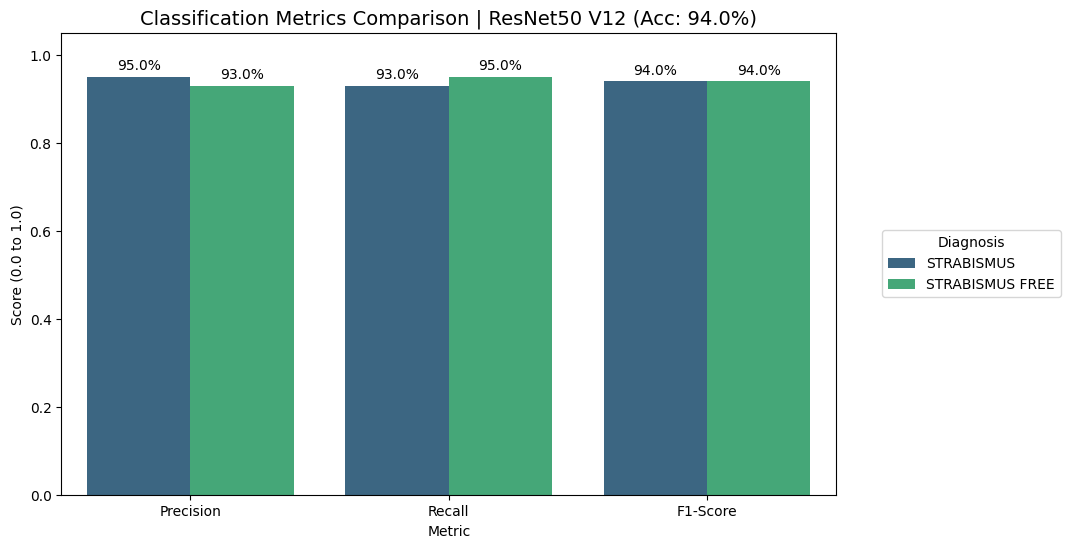

In [ ]:
# --- FINAL ARRANGED AND ROBUST CLASSIFICATION GRAPH CODE ---
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. SETUP & UTILITY FUNCTION ---
SAVE_PATH = '/content/drive/MyDrive/v11_improved'
TXT_PATH = os.path.join(SAVE_PATH, 'classification_report_v12.txt')
TEST_ACCURACY = 94.0 # Default value, will be updated by parsing

def parse_classification_report(report_text):
    """Parses the raw classification report text using regex to extract metrics."""

    class_names = ['STRABISMUS', 'STRABISMUS_FREE']
    parsed_metrics = {}

    for name in class_names:
        # NOTE: Using a raw string (r'') and non-capturing groups for internal separation
        # is the clean way to define this pattern.
        pattern = re.compile(rf'^\s*{name}\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+\d+', re.MULTILINE)

        match = pattern.search(report_text)

        if match:
            # Group 1: Precision, Group 2: Recall, Group 3: F1-Score
            parsed_metrics[name] = {
                'Precision': float(match.group(1)),
                'Recall': float(match.group(2)),
                'F1-Score': float(match.group(3))
            }
        else:
            print(f"Warning: Could not find metrics for class: {name}")
            parsed_metrics[name] = {'Precision': 0.0, 'Recall': 0.0, 'F1-Score': 0.0}

    return parsed_metrics

# 2. Read and Parse the Report
print(f"Reading Classification Report from: {TXT_PATH}")
try:
    with open(TXT_PATH, 'r') as f:
        report_text = f.read()

    # Extract overall accuracy for the title
    match_acc = re.search(r'accuracy\s+(\d+\.\d+)', report_text)
    global TEST_ACCURACY
    TEST_ACCURACY = float(match_acc.group(1)) * 100 if match_acc else 94.0

    REPORT_METRICS = parse_classification_report(report_text)

except FileNotFoundError:
    print(f"CRITICAL ERROR: Classification report TXT file not found at {TXT_PATH}. Aborting.")
    exit()

# 3. Prepare DataFrame for Plotting (Melting the data)
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
df_list = []

for cls, metrics in REPORT_METRICS.items():
    for metric_name in metrics_to_plot:
        df_list.append({
            'Class': cls.replace('_', ' '),
            'Metric': metric_name,
            'Score': metrics[metric_name]
        })

df = pd.DataFrame(df_list)
# Convert scores to percentages for display labels
df['Percentage'] = (df['Score'] * 100).round(1)

# 4. Create Grouped Bar Chart (Plotting)
plt.figure(figsize=(10, 6))
class_order = ['STRABISMUS', 'STRABISMUS_FREE']
df['Class'] = pd.Categorical(df['Class'], categories=[c.replace('_', ' ') for c in class_order], ordered=True)

ax = sns.barplot(x='Metric', y='Score', hue='Class', data=df.sort_values(by='Class'), palette='viridis')

# 5. Add Percentage Labels
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=10)

# 6. Final Plot Customization and Saving (Legend Fix)
plt.ylim(0, 1.05)
plt.title(f'Classification Metrics Comparison | ResNet50 V12 (Acc: {TEST_ACCURACY:.1f}%)', fontsize=14)
plt.ylabel('Score (0.0 to 1.0)')
plt.xlabel('Metric')

# --- LEGEND FIX APPLIED ---
# Move the legend outside the plot area to prevent overlapping the percentage labels.
plt.legend(title='Diagnosis', loc='center left', bbox_to_anchor=(1.05, 0.5))

graph_path = os.path.join(SAVE_PATH, 'classification_report_graph_final_arranged.png')
plt.savefig(graph_path, bbox_inches='tight')

print(f"\n Final Classification Report Graph saved with adjusted legend position to: {graph_path}")